<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/Homework_Clustering_Mall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# 1. Cargar el dataset
df = pd.read_csv('Mall_Customers.csv')

# Vistazo rápido
display(df.head())

# 2. Limpieza básica
# Eliminamos 'CustomerID' porque es un identificador, no un comportamiento.
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

print(f"Valores nulos:\n{X.isnull().sum()}\n")

# 3. Escalamiento (StandardScaler)
# K-Means calcula distancias euclidianas. Si no escalamos,
# la diferencia de ingresos dominará la formación de grupos.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos listos y estandarizados para el clustering.")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Valores nulos:
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Datos listos y estandarizados para el clustering.


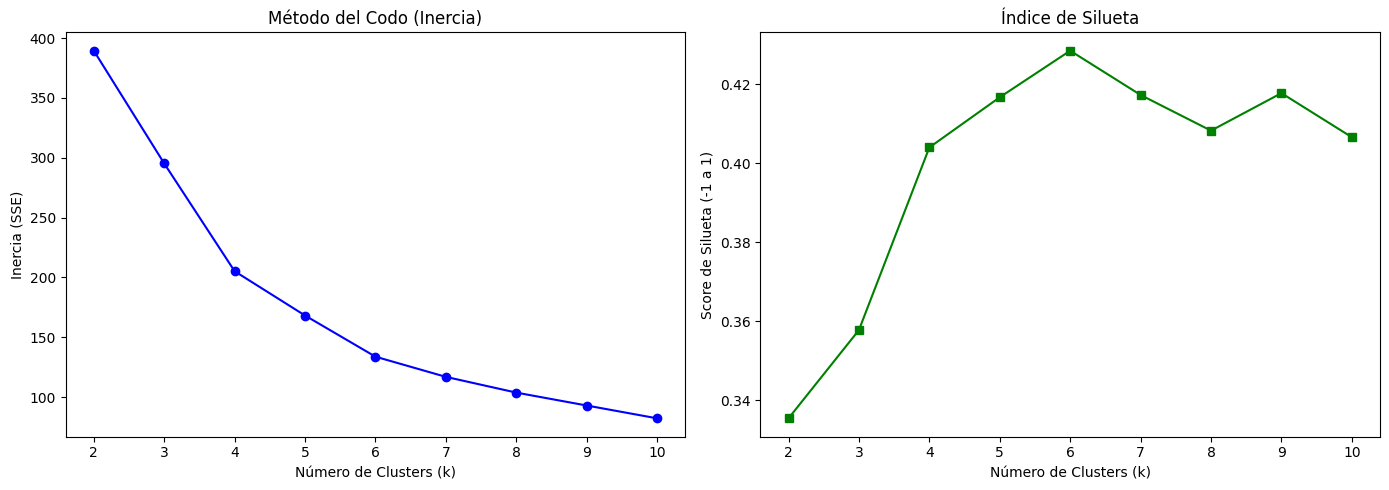

In [2]:
# Listas para guardar las métricas
inercias = []
siluetas = []
rango_k = range(2, 11) # Probaremos K desde 2 hasta 10

# Bucle para probar distintos valores de K
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    # Inercia para el método del codo
    inercias.append(kmeans.inertia_)

    # Score de Silueta
    silueta = silhouette_score(X_scaled, kmeans.labels_)
    siluetas.append(silueta)

# Graficar los resultados
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Método del Codo
ax[0].plot(rango_k, inercias, marker='o', color='blue')
ax[0].set_title('Método del Codo (Inercia)')
ax[0].set_xlabel('Número de Clusters (k)')
ax[0].set_ylabel('Inercia (SSE)')

# Gráfico 2: Índice de Silueta
ax[1].plot(rango_k, siluetas, marker='s', color='green')
ax[1].set_title('Índice de Silueta')
ax[1].set_xlabel('Número de Clusters (k)')
ax[1].set_ylabel('Score de Silueta (-1 a 1)')

plt.tight_layout()
plt.show()

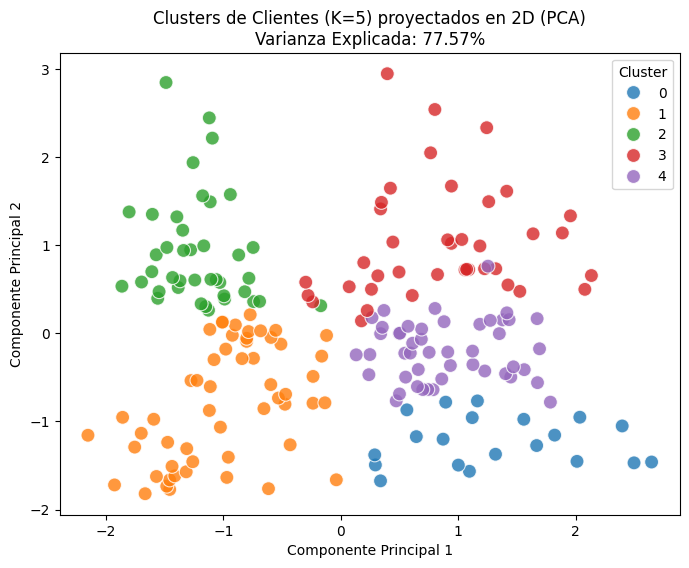


Perfil Promedio de Cada Cluster


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.2,26.8,18.4
1,25.2,41.1,62.2
2,32.9,86.1,81.5
3,39.9,86.1,19.4
4,55.6,54.4,48.9


In [4]:
# 1. Entrena el modelo óptimo (Elegimos k=5 basado en las métricas)
kmeans_optimo = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans_optimo.fit_predict(X_scaled)

# 2. Aplicar PCA (Reducción a 2 dimensiones para visualizar)
# Tenemos 3 variables (3D) y nuestra pantalla es 2D.
# PCA condensa la información para que podamos dibujarla.
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(X_scaled)

df['PCA1'] = componentes_pca[:, 0]
df['PCA2'] = componentes_pca[:, 1]

# 3. Visualiza los Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PCA1', y='PCA2',
    hue='Cluster', palette='tab10', s=100, alpha=0.8
)
plt.title(f'Clusters de Clientes (K=5) proyectados en 2D (PCA)\nVarianza Explicada: {pca.explained_variance_ratio_.sum():.2%}')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.show()

# 4. Calcula los promedios de cada cluster para interpretarlos
resumen_clusters = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print("\nPerfil Promedio de Cada Cluster")
display(resumen_clusters)

**Reporte Final de Modelos Predictivos: Prevención de Churn en FinanceGuard**

1. Resumen Ejecutivo
FinanceGuard, un banco digital con 10,000 clientes activos, enfrenta una tasa de abandono (churn) del 20% anual. El presente proyecto tuvo como objetivo desarrollar un modelo de Machine Learning capaz de identificar proactivamente a los clientes con alta probabilidad de fuga, permitiendo al equipo de retención focalizar sus esfuerzos y reducir la tasa de churn al 15%.

A lo largo de la investigación, se evaluaron múltiples enfoques, desde modelos lineales simples hasta arquitecturas avanzadas de ensamblado (Stacking), logrando una mejora drástica en la capacidad de detección (Recall).

2. Metodología y Procesamiento de Datos
Para garantizar la calidad de las predicciones, se implementó el siguiente pipeline de datos:

Limpieza: Se eliminaron variables de identificación sin valor predictivo (RowNumber, CustomerId, Surname).

Encoding: Se aplicó One-Hot Encoding a las variables categóricas (País y Género).

Escalamiento: Las variables continuas (CreditScore, Age, Balance, etc.) fueron estandarizadas utilizando StandardScaler.

Validación: Se utilizó un split estratificado (80/20) y StratifiedKFold durante la optimización para respetar la proporción original de la clase minoritaria (20% de churn).

3. Comparativa de Modelos y Evolución de Métricas
El desarrollo de modelos se realizó de forma iterativa, priorizando el Recall de la clase 1 (capacidad de encontrar a los clientes que se van) y el PR-AUC (precisión-recall en clases desbalanceadas).

Fase 1: Modelo Baseline (Regresión Logística)
ROC-AUC: 0.7748

Recall (Clase 1): 0.19

Diagnóstico: El modelo base presentó un alto nivel de sesgo (Underfitting para la clase minoritaria). Al ser un modelo lineal, no logró capturar las relaciones complejas del comportamiento del cliente, omitiendo al 81% de las fugas reales.

Fase 2: Modelos de Ensamble (Gradient Boosting)
Se introdujeron algoritmos basados en árboles (Random Forest, XGBoost, LightGBM y CatBoost) aplicando balanceo de clases algorítmico (scale_pos_weight y class_weight='balanced').

Tras optimizar XGBoost mediante GridSearchCV (learning_rate=0.1, max_depth=3, n_estimators=100), se logró un salto evolutivo:

ROC-AUC: 0.8689

Recall (Clase 1): 0.77

PR-AUC: 0.7161

Fase 3: Arquitectura Final (Stacking Classifier)
Para exprimir al máximo el rendimiento, se construyó un ensamble de Stacking.

Nivel 1 (Modelos Base): XGBoost Optimizado, LightGBM y CatBoost.

Nivel 2 (Meta-Learner): Regresión Logística regularizada.

Resultados Finales:

ROC-AUC: 0.8689

PR-AUC: 0.7196 (El más alto del experimento)

Recall: 0.76

Veredicto: El modelo de Stacking es la solución definitiva. La Regresión Logística de segundo nivel aprendió a combinar las fortalezas de los tres algoritmos de Boosting, entregando la predicción más estable y precisa para la clase minoritaria.

4. Insights de Negocio (Análisis de Factores de Riesgo)
A partir del análisis de Feature Importance y de los Odds Ratios de la regresión logística inicial, identificamos los 3 motores principales del churn en FinanceGuard:

La Edad (Age): Existe una correlación directa entre la madurez del cliente y el riesgo de abandono. Los clientes de mayor edad son estadísticamente más propensos a cerrar sus cuentas.

Geografía (Germany): Residir en Alemania prácticamente duplica el riesgo de fuga frente a clientes en Francia o España. Esto sugiere una desconexión entre la oferta de productos actual y las expectativas del mercado alemán.

Falta de Interacción (IsActiveMember): Ser un miembro inactivo es un predictor letal. Por el contrario, los clientes catalogados como "activos" tienen un riesgo de fuga drásticamente menor (Odds Ratio de ~0.35).

5. Recomendaciones Estratégicas
Con base en los resultados del modelo de Stacking, se recomiendan las siguientes acciones inmediatas para alcanzar la meta de reducir el churn al 15%:

Implementación del Sistema de Scoring: Desplegar el modelo de Stacking en producción para puntear a toda la base de clientes mensualmente. El equipo de retención debe enfocar el 100% de su presupuesto en el decil de clientes con mayor probabilidad de fuga dictada por el algoritmo.

Campaña de Reactivación (Engagement): Dado que la inactividad es el factor de riesgo más mitigable, Marketing debe lanzar campañas de engagement (ej. devoluciones en compras con tarjeta, beneficios por uso de la app) para forzar la interacción de los usuarios inactivos y convertirlos en IsActiveMember = 1.

Revisión del Mercado Alemán: Se requiere una investigación urgente liderada por el equipo de Producto sobre las condiciones competitivas en Alemania. El modelo advierte una fuga sistémica en esta región que no se soluciona solo con marketing, sino probablemente con tasas de interés o comisiones más competitivas.